This script was made to produce visualization plots for the external validation.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
path_pos = "/home/ioannis/thesis_data/positive_test_results_filtered_2/prioritized_motifs_filtered_2.xlsx"
path_neg = "/home/ioannis/thesis_data/negative_test_results_filtered/neg_prioritized_motifs_filtered_2.xlsx"

In [3]:
df_pos = pd.read_excel(path_pos)
df_neg = pd.read_excel(path_neg)

In [4]:
top20_pos = df_pos.nlargest(20, "predicted_score")
top20_neg = df_neg.nlargest(20, "predicted_score")

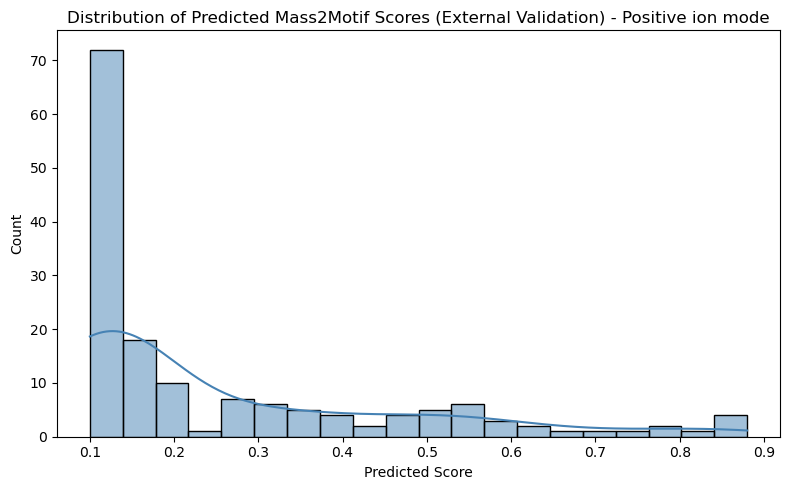

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df_pos['predicted_score'], bins=20, kde=True, color='steelblue')
plt.xlabel("Predicted Score")
plt.ylabel("Count")
plt.title("Distribution of Predicted Mass2Motif Scores (External Validation) - Positive ion mode")
plt.tight_layout()
plt.show()


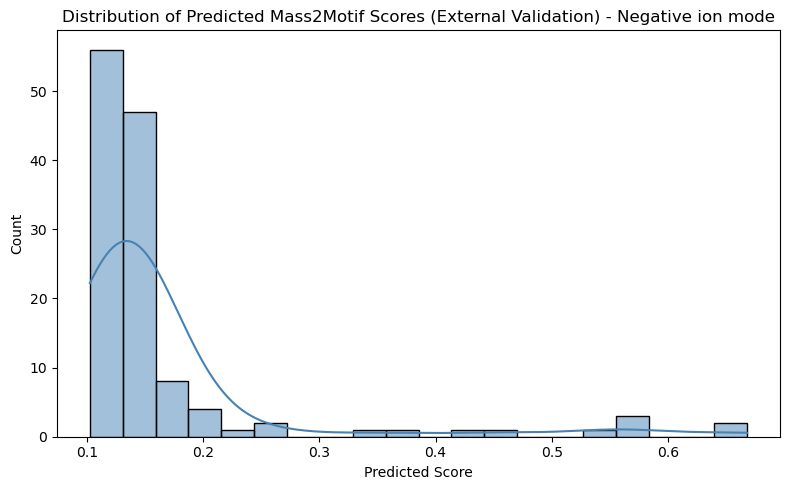

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df_neg['predicted_score'], bins=20, kde=True, color='steelblue')
plt.xlabel("Predicted Score")
plt.ylabel("Count")
plt.title("Distribution of Predicted Mass2Motif Scores (External Validation) - Negative ion mode")
plt.tight_layout()
plt.show()


In [7]:
df_pos['rank'] = range(1, len(df_pos) + 1)
df_neg['rank'] = range(1, len(df_neg) + 1)


For just visual representation, only peak_max, mcs_support and mcs_size will be used as criteria for Mass2Motif relevance, as they where the most significant features.

In [8]:
def classify_motif(row, mode="pos"):
    # thresholds differ slightly between modes
    if mode == "pos":
        strong_peak = row['peak_max'] >= 0.70
    else:
        strong_peak = row['peak_max'] >= 0.60

    if row['mcs_size'] >= 3 and row['mcs_support'] >= 0.5 and strong_peak:
        return "relevant"
    if row['mcs_size'] < 3 or row['mcs_support'] <= 0.3 or row['peak_max'] < 0.5:
        return "noisy"
    return "borderline"

df_pos['quality'] = df_pos.apply(lambda r: classify_motif(r, mode="pos"), axis=1)
df_neg['quality'] = df_neg.apply(lambda r: classify_motif(r, mode="neg"), axis=1)


In [15]:
def plot_rank_vs_score(df, title):
    plt.figure(figsize=(8,6))
    ax = sns.scatterplot(
        data=df,
        x='rank',
        y='predicted_score',
        hue='quality',
        palette={'relevant':'green','borderline':'orange','noisy':'red'},
        s=90
    )
    
    plt.gca().invert_xaxis()  # rank 1 on the left

    # Axis labels
    plt.xlabel("Rank (1 = highest relevance)", fontsize=16)
    plt.ylabel("Predicted score", fontsize=16)

    # Title
    plt.title(title, fontsize=16)

    # Bigger tick labels
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)

    # Legend formatting
    legend = ax.legend()
    legend.set_title("")
    for text in legend.texts:
        text.set_fontsize(16)
        text.set_fontweight("bold")

    plt.tight_layout()
    plt.show()



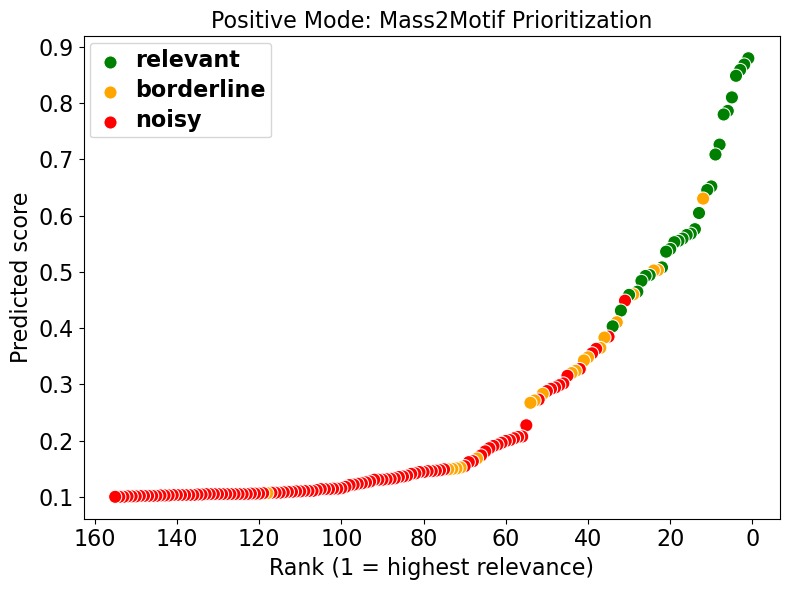

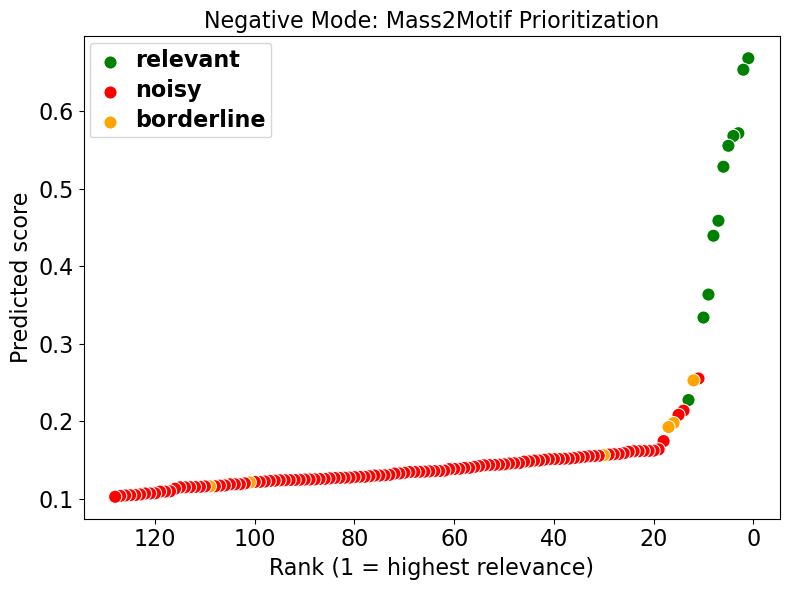

In [16]:
plot_rank_vs_score(df_pos, "Positive Mode: Mass2Motif Prioritization")
plot_rank_vs_score(df_neg, "Negative Mode: Mass2Motif Prioritization")